In [1]:
!pip install numpy scipy matplotlib scikit-learn torch -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import multivariate_normal

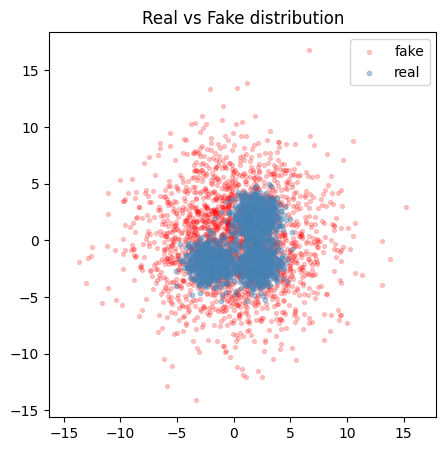

In [3]:
MEANS   = np.array([[2.0, 2.0], [-2.0, -2.0], [2.0, -2.0]])
WEIGHTS = np.array([0.4, 0.3, 0.3])
COV     = np.eye(2)
DELTA   = 0.1
C1      = 2.0 / (DELTA ** 2)   # = 200

def sample_data(n=2000):
    samples = []
    for _ in range(n):
        k = np.random.choice(3, p=WEIGHTS)
        x = np.random.multivariate_normal(MEANS[k], COV)
        samples.append(x)
    return np.array(samples)

def sample_fake(n=2000):
    # Wide Gaussian — clearly separable from the tight real clusters
    return np.random.randn(n, 2) * 4.0

# Visual check
real_data = sample_data(2000)
fake_data = sample_fake(2000)
plt.figure(figsize=(5,5))
plt.scatter(fake_data[:,0], fake_data[:,1], alpha=0.2, s=8,  c='red',      label='fake')
plt.scatter(real_data[:,0], real_data[:,1], alpha=0.4, s=10, c='steelblue',label='real')
plt.title("Real vs Fake distribution")
plt.legend()
plt.axis('equal')
plt.show()

In [4]:
def true_score(x):
    """
    Analytically computed score of the Gaussian mixture.
    For each point x, returns the gradient of log p_data(x).
    Shape in: (N, 2) — Shape out: (N, 2)
    """
    x = np.atleast_2d(x)
    N = x.shape[0]

    densities = np.zeros((N, 3))
    gradients = np.zeros((N, 3, 2))

    for k in range(3):
        rv = multivariate_normal(mean=MEANS[k], cov=COV)
        densities[:, k] = WEIGHTS[k] * rv.pdf(x)
        # Gradient of log p_k(x) for isotropic Gaussian = -(x - mu_k)
        gradients[:, k, :] = -(x - MEANS[k])

    p_total = densities.sum(axis=1, keepdims=True)  # shape (N,1)
    p_total = np.clip(p_total, 1e-10, None)         # avoid divide by zero

    score = np.zeros((N, 2))
    for k in range(3):
        weight_k = densities[:, k:k+1] / p_total
        score   += weight_k * gradients[:, k, :]

    return score

# Sanity check
# Point (3, 2) is right of cluster 1 at (2,2) — score should point left
s = true_score(np.array([[3.0, 2.0]]))
print(f"Score at (3,2): {s}")
print(f"x-component should be negative: {s[0,0]:.3f}  ✓" if s[0,0] < 0 else "Something is wrong")

Score at (3,2): [[-1.00000001 -0.00100614]]
x-component should be negative: -1.000  ✓


In [5]:
class Discriminator(nn.Module):
    """
    MLP that learns to distinguish real data from fake noise.
    Input:  2D point
    Output: scalar in [0,1] — probability of being real
    """
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.LeakyReLU(0.2),        # LeakyReLU works better than ReLU for discriminators
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def train_discriminator(n_epochs, n_samples=3000, hidden_dim=128, lr=3e-3):
    """
    Train a discriminator for n_epochs.
    Fewer epochs = weaker discriminator = larger epsilon_D.
    """
    D         = Discriminator(hidden_dim)
    optimizer = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    loss_fn   = nn.BCELoss()

    for epoch in range(n_epochs):
        real = torch.tensor(sample_data(n_samples), dtype=torch.float32)
        fake = torch.tensor(sample_fake(n_samples), dtype=torch.float32)

        real_labels = torch.ones(n_samples,  1)
        fake_labels = torch.zeros(n_samples, 1)

        loss = loss_fn(D(real), real_labels) + loss_fn(D(fake), fake_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return D

In [7]:
# More epochs = better discriminator = smaller epsilon_D
EPOCH_LEVELS = [2, 10, 30, 80, 200]

print("Training discriminators...\n")
discriminators = []

for epochs in EPOCH_LEVELS:
    D = train_discriminator(n_epochs=epochs)
    discriminators.append(D)
    # Quick check on real data
    x_check = torch.tensor(sample_data(500), dtype=torch.float32)
    with torch.no_grad():
        out = D(x_check)
    print(f"epochs={epochs:>4} | mean={out.mean():.3f} | "
          f"min={out.min():.3f} | max={out.max():.3f}")

Training discriminators...

epochs=   2 | mean=0.451 | min=0.244 | max=0.512
epochs=  10 | mean=0.600 | min=0.111 | max=0.774
epochs=  30 | mean=0.703 | min=0.032 | max=0.836
epochs=  80 | mean=0.751 | min=0.041 | max=0.899
epochs= 200 | mean=0.709 | min=0.026 | max=0.895


In [8]:
def compute_epsilon_D(D, n_points=1000):
    """
    Measure how far trained D is from the optimal D*.
    Uses analytical D*(x) = p_data(x) / (p_data(x) + p_fake(x))
    """
    x_test   = sample_data(n_points)
    x_tensor = torch.tensor(x_test, dtype=torch.float32)

    with torch.no_grad():
        d_theta = D(x_tensor).numpy().flatten()

    # Analytical p_data at test points
    p_data_vals = sum(
        w * multivariate_normal(mean=m, cov=COV).pdf(x_test)
        for w, m in zip(WEIGHTS, MEANS)
    )

    # Analytical p_fake — matches sample_fake() which is N(0, 16I)
    p_fake_vals = multivariate_normal(mean=[0.0, 0.0], cov=np.eye(2)*16).pdf(x_test)

    # Optimal discriminator
    d_star = p_data_vals / (p_data_vals + p_fake_vals)
    d_star = np.clip(d_star, DELTA, 1 - DELTA)

    epsilon_D = np.sqrt(np.mean((d_theta - d_star)**2))
    return float(epsilon_D)

In [9]:
def dsg_guidance_grad(D, x_np):
    """
    Computes grad_x log[ D(x) / (1 - D(x)) ] at each point in x_np.
    This is Proposition 1 in code — the DSG guidance signal.
    Shape in: (N, 2) — Shape out: (N, 2)
    """
    x_tensor = torch.tensor(x_np, dtype=torch.float32, requires_grad=True)

    d_out    = D(x_tensor).clamp(DELTA, 1 - DELTA)
    log_odds = torch.log(d_out) - torch.log(1 - d_out)
    log_odds.sum().backward()

    return x_tensor.grad.detach().numpy()

In [10]:
# Fixed test points — same for all discriminators so comparison is fair
X_TEST      = sample_data(800)
TRUE_SCORES = true_score(X_TEST)

epsilon_Ds     = []
guidance_errors = []

print("Computing errors...\n")
for i, (D, epochs) in enumerate(zip(discriminators, EPOCH_LEVELS)):
    # Epsilon_D — how far D is from optimal
    eps = compute_epsilon_D(D)

    # Guidance error — how far DSG gradient is from true score
    dsg_grads = dsg_guidance_grad(D, X_TEST)
    err = float(np.mean(np.linalg.norm(dsg_grads - TRUE_SCORES, axis=1)))

    # Theorem 1 bound
    bound = C1 * eps

    epsilon_Ds.append(eps)
    guidance_errors.append(err)

    print(f"epochs={epochs:>4} | ε_D={eps:.4f} | "
          f"guidance error={err:.4f} | "
          f"bound={bound:.4f} | "
          f"below bound: {err < bound}")

Computing errors...

epochs=   2 | ε_D=0.3163 | guidance error=1.0398 | bound=63.2602 | below bound: True
epochs=  10 | ε_D=0.2026 | guidance error=0.8137 | bound=40.5300 | below bound: True
epochs=  30 | ε_D=0.0965 | guidance error=0.5517 | bound=19.2920 | below bound: True
epochs=  80 | ε_D=0.0497 | guidance error=0.4175 | bound=9.9499 | below bound: True
epochs= 200 | ε_D=0.0428 | guidance error=0.2921 | bound=8.5557 | below bound: True


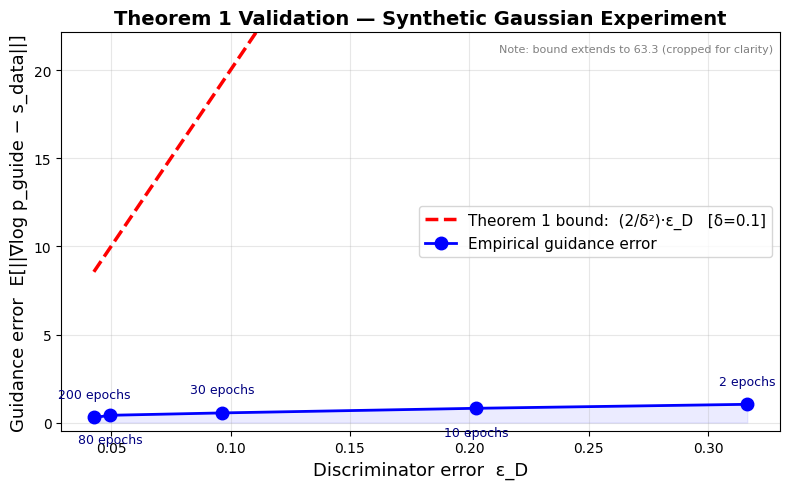


--- Theorem 1 Verification ---
epochs=   2 | ε_D=0.3163 | error=1.0398 | bound=63.2602 | ✓ PASS
epochs=  10 | ε_D=0.2026 | error=0.8137 | bound=40.5300 | ✓ PASS
epochs=  30 | ε_D=0.0965 | error=0.5517 | bound=19.2920 | ✓ PASS
epochs=  80 | ε_D=0.0497 | error=0.4175 | bound=9.9499 | ✓ PASS
epochs= 200 | ε_D=0.0428 | error=0.2921 | bound=8.5557 | ✓ PASS


In [11]:
epsilon_D_arr  = np.array(epsilon_Ds)
error_arr      = np.array(guidance_errors)
bound_arr      = C1 * epsilon_D_arr

# Sort by epsilon_D for clean left-to-right plot
idx     = np.argsort(epsilon_D_arr)
eps_s   = epsilon_D_arr[idx]
err_s   = error_arr[idx]
bound_s = bound_arr[idx]
epoch_s = np.array(EPOCH_LEVELS)[idx]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(eps_s, bound_s, 'r--', linewidth=2.5,
        label=f'Theorem 1 bound:  (2/δ²)·ε_D   [δ={DELTA}]')
ax.plot(eps_s, err_s,   'bo-', linewidth=2, markersize=9,
        label='Empirical guidance error')
ax.fill_between(eps_s, 0, err_s, alpha=0.08, color='blue')

# Alternating label positions so they don't stack
for i, (e, er, ep) in enumerate(zip(eps_s, err_s, epoch_s)):
    offset = 14 if i % 2 == 0 else -20
    ax.annotate(f'{ep} epochs', xy=(e, er),
                xytext=(0, offset), textcoords='offset points',
                ha='center', fontsize=9, color='navy')

# Zoom y-axis so the error trend is visible, not swamped by the bound
ax.set_ylim(-0.5, bound_s.max() * 0.35)

ax.set_xlabel('Discriminator error  ε_D',                      fontsize=13)
ax.set_ylabel('Guidance error  E[||∇log p_guide − s_data||]',  fontsize=13)
ax.set_title('Theorem 1 Validation — Synthetic Gaussian Experiment',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Note explaining the cropped bound
ax.text(0.99, 0.97,
        f'Note: bound extends to {bound_s.max():.1f} (cropped for clarity)',
        transform=ax.transAxes, fontsize=8, color='gray',
        ha='right', va='top')

plt.tight_layout()
plt.savefig('figure1_theorem1_validation.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Final verdict
print("\n--- Theorem 1 Verification ---")
for ep, eps, err, bound in zip(EPOCH_LEVELS,
                                epsilon_D_arr, error_arr, bound_arr):
    status = "✓ PASS" if err < bound else "✗ FAIL"
    print(f"epochs={ep:>4} | ε_D={eps:.4f} | "
          f"error={err:.4f} | bound={bound:.4f} | {status}")

In [12]:
tightness = error_arr / bound_arr
print("Tightness ratio (error / bound):")
for ep, t in zip(EPOCH_LEVELS, tightness):
    print(f"  epochs={ep:>4} | ratio={t:.4f}  ({t*100:.2f}% of bound used)")

Tightness ratio (error / bound):
  epochs=   2 | ratio=0.0164  (1.64% of bound used)
  epochs=  10 | ratio=0.0201  (2.01% of bound used)
  epochs=  30 | ratio=0.0286  (2.86% of bound used)
  epochs=  80 | ratio=0.0420  (4.20% of bound used)
  epochs= 200 | ratio=0.0341  (3.41% of bound used)


In [13]:
def compute_cosine_alignment(D, x_test, true_scores):
    """
    Measures whether DSG gradient POINTS IN THE RIGHT DIRECTION
    even if its magnitude is off. Cosine similarity of 1.0 = perfect direction.
    """
    dsg_grads = dsg_guidance_grad(D, x_test)

    # Cosine similarity between DSG gradient and true score at each point
    dot     = np.sum(dsg_grads * true_scores, axis=1)
    norm_dsg   = np.linalg.norm(dsg_grads,   axis=1) + 1e-8
    norm_true  = np.linalg.norm(true_scores, axis=1) + 1e-8
    cosine  = dot / (norm_dsg * norm_true)
    return float(np.mean(cosine))

alignments = []
for D in discriminators:
    a = compute_cosine_alignment(D, X_TEST, TRUE_SCORES)
    alignments.append(a)

for ep, a in zip(EPOCH_LEVELS, alignments):
    print(f"epochs={ep:>4} | cosine alignment={a:.4f}")

epochs=   2 | cosine alignment=0.4054
epochs=  10 | cosine alignment=0.5680
epochs=  30 | cosine alignment=0.8097
epochs=  80 | cosine alignment=0.8349
epochs= 200 | cosine alignment=0.9485
